Environment Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Data Loading (identik dengan isolation_forest.ipynb)

In [6]:
# Path relatif dari folder "Anomaly Detection BMKG" ke folder "data"
file_path = '../data/bmkg/gabungan_2008_2025.csv'

# Load data
df = pd.read_csv(file_path)

print(f"Dataset berhasil dimuat dengan dimensi: {df.shape}")
df.head()

Dataset berhasil dimuat dengan dimensi: (131130, 6)


,time,latitude,longitude,depth,mag,wilayah
0,2008-11-01 00:31:25.143741+00:00,-0.604440,98.895531,20,2.989742,"Southern Sumatra, Indonesia"
1,2008-11-01 01:34:29.660856+00:00,-6.611860,129.387220,30,5.507549,Banda Sea
2,2008-11-01 01:38:14.802129+00:00,-3.650586,127.990680,5,3.539674,"Seram, Indonesia"
3,2008-11-01 02:20:05.909515+00:00,-4.198925,128.097000,5,2.424314,Banda Sea
4,2008-11-01 02:32:18.756155+00:00,-4.091891,128.200470,10,2.410045,Banda Sea


Data Preparation (identik dengan isolation_forest.ipynb)

In [7]:
# Menampilkan jumlah awal
print(f"Jumlah data awal: {len(df)}")

# Batas koordinat geografis Indonesia (secara kasar / bounding box)
lat_min, lat_max = -11.0, 6.0
lon_min, lon_max = 95.0, 141.0

# 1. Filter hanya koordinat yang berada di dalam bounding box Indonesia
df = df[(df['latitude'] >= lat_min) & (df['latitude'] <= lat_max) &
        (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)]
print(f"Jumlah data setelah difilter wilayah Indonesia: {len(df)}")

# 2. Menghapus semua baris yang memiliki nilai kosong (NaN)
df = df.dropna()
print(f"Jumlah data setelah drop missing values: {len(df)}")

# 3. Merapikan (reset) index setelah ada penghapusan baris
df = df.reset_index(drop=True)

df.info()

Jumlah data awal: 131130
Jumlah data setelah difilter wilayah Indonesia: 131130
Jumlah data setelah drop missing values: 131117
<class 'pandas.DataFrame'>
RangeIndex: 131117 entries, 0 to 131116
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       131117 non-null  str    
 1   latitude   131117 non-null  float64
 2   longitude  131117 non-null  float64
 3   depth      131117 non-null  int64  
 4   mag        131117 non-null  float64
 5   wilayah    131117 non-null  str    
dtypes: float64(3), int64(1), str(2)
memory usage: 6.0 MB


Feature Engineering & Preprocessing (identik dengan isolation_forest.ipynb)

In [8]:
# Pilih fitur sesuai kriteria proyek
features = ['mag', 'depth', 'latitude', 'longitude']
X = df[features]

# Standarisasi menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Mean setelah di-scale (harus mendekati 0):")
print(X_scaled_df.mean())
print("\nStandard Deviation setelah di-scale (harus mendekati 1):")
print(X_scaled_df.std())

Mean setelah di-scale (harus mendekati 0):
mag         -2.080954e-16
depth        3.815082e-17
latitude     1.560715e-17
longitude   -7.161949e-16
dtype: float64

Standard Deviation setelah di-scale (harus mendekati 1):
mag          1.000004
depth        1.000004
latitude     1.000004
longitude    1.000004
dtype: float64


# Perbandingan Antar Nilai Contamination
Melatih beberapa model Isolation Forest dengan nilai *contamination* berbeda di atas data yang sama persis (`X_scaled_df`), lalu membandingkan hasilnya.

In [11]:
# Daftar nilai contamination yang ingin dibandingkan
contaminations = [0.001, 0.005, 0.01, 0.02, 0.05]

results = {}
total_data = len(X_scaled_df)

for cont in contaminations:
    iso_forest = IsolationForest(contamination=cont, random_state=42)
    labels = iso_forest.fit_predict(X_scaled_df)
    scores = iso_forest.decision_function(X_scaled_df)

    total_anomaly = (labels == -1).sum()
    total_normal = (labels == 1).sum()
    persentase = (total_anomaly / total_data) * 100


    results[cont] = {
        'model': iso_forest,
        'labels': labels,
        'scores': scores,
        'total_normal': total_normal,
        'total_anomaly': total_anomaly,
        'persentase_anomaly': persentase,
        'mean_score_normal': scores[labels == 1].mean(),
        'mean_score_anomaly': scores[labels == -1].mean(),
    }

    print(f"[ Contamination {cont} ]")
    print(f"Total Normal   : {total_normal}")
    print(f"Total Anomaly  : {total_anomaly}")
    print(f"Persentase     : {persentase:.3f}%")
    print(f"Mean Score (Normal)  : {results[cont]['mean_score_normal']:.4f}")
    print(f"Mean Score (Anomaly) : {results[cont]['mean_score_anomaly']:.4f}")
    print("-" * 40)

[ Contamination 0.001 ]
Total Normal   : 130985
Total Anomaly  : 132
Persentase     : 0.101%
Mean Score (Normal)  : 0.2357
Mean Score (Anomaly) : -0.0159
----------------------------------------
[ Contamination 0.005 ]
Total Normal   : 130461
Total Anomaly  : 656
Persentase     : 0.500%
Mean Score (Normal)  : 0.1990
Mean Score (Anomaly) : -0.0224
----------------------------------------
[ Contamination 0.01 ]
Total Normal   : 129805
Total Anomaly  : 1312
Persentase     : 1.001%
Mean Score (Normal)  : 0.1727
Mean Score (Anomaly) : -0.0308
----------------------------------------
[ Contamination 0.02 ]
Total Normal   : 128494
Total Anomaly  : 2623
Persentase     : 2.001%
Mean Score (Normal)  : 0.1410
Mean Score (Anomaly) : -0.0401
----------------------------------------
[ Contamination 0.05 ]
Total Normal   : 124561
Total Anomaly  : 6556
Persentase     : 5.000%
Mean Score (Normal)  : 0.1045
Mean Score (Anomaly) : -0.0419
----------------------------------------


## Tabel Ringkasan Perbandingan

In [12]:
summary = pd.DataFrame([
    {
        'Contamination': cont,
        'Total Normal': r['total_normal'],
        'Total Anomaly': r['total_anomaly'],
        'Persentase Anomaly (%)': round(r['persentase_anomaly'], 3),
        'Mean Score Normal': round(r['mean_score_normal'], 4),
        'Mean Score Anomaly': round(r['mean_score_anomaly'], 4),
    }
    for cont, r in results.items()
])

display(summary)

,Contamination,Total Normal,Total Anomaly,Persentase Anomaly (%),Mean Score Normal,Mean Score Anomaly
0,0.001,130985,132,0.101,0.2357,-0.0159
1,0.005,130461,656,0.500,0.1990,-0.0224
2,0.010,129805,1312,1.001,0.1727,-0.0308
3,0.020,128494,2623,2.001,0.1410,-0.0401
4,0.050,124561,6556,5.000,0.1045,-0.0419


## Visualisasi: Jumlah Anomali per Nilai Contamination

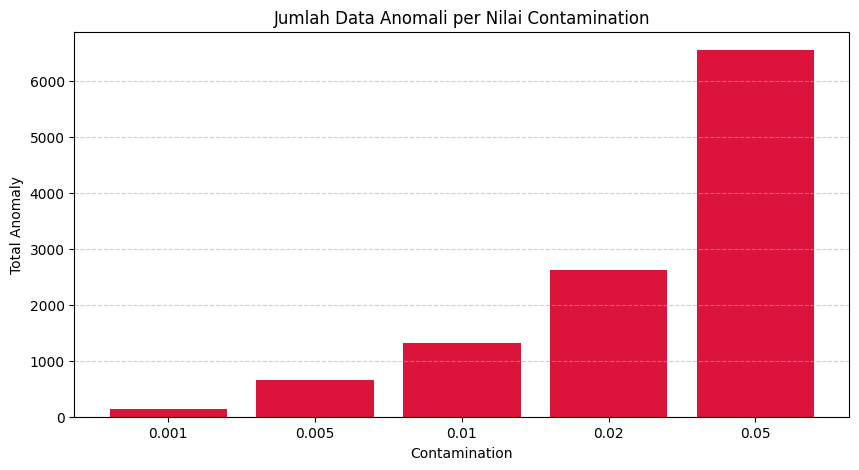

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(summary['Contamination'].astype(str), summary['Total Anomaly'], color='crimson')
plt.title('Jumlah Data Anomali per Nilai Contamination')
plt.xlabel('Contamination')
plt.ylabel('Total Anomaly')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Visualisasi: Sebaran Lokasi Anomali per Nilai Contamination

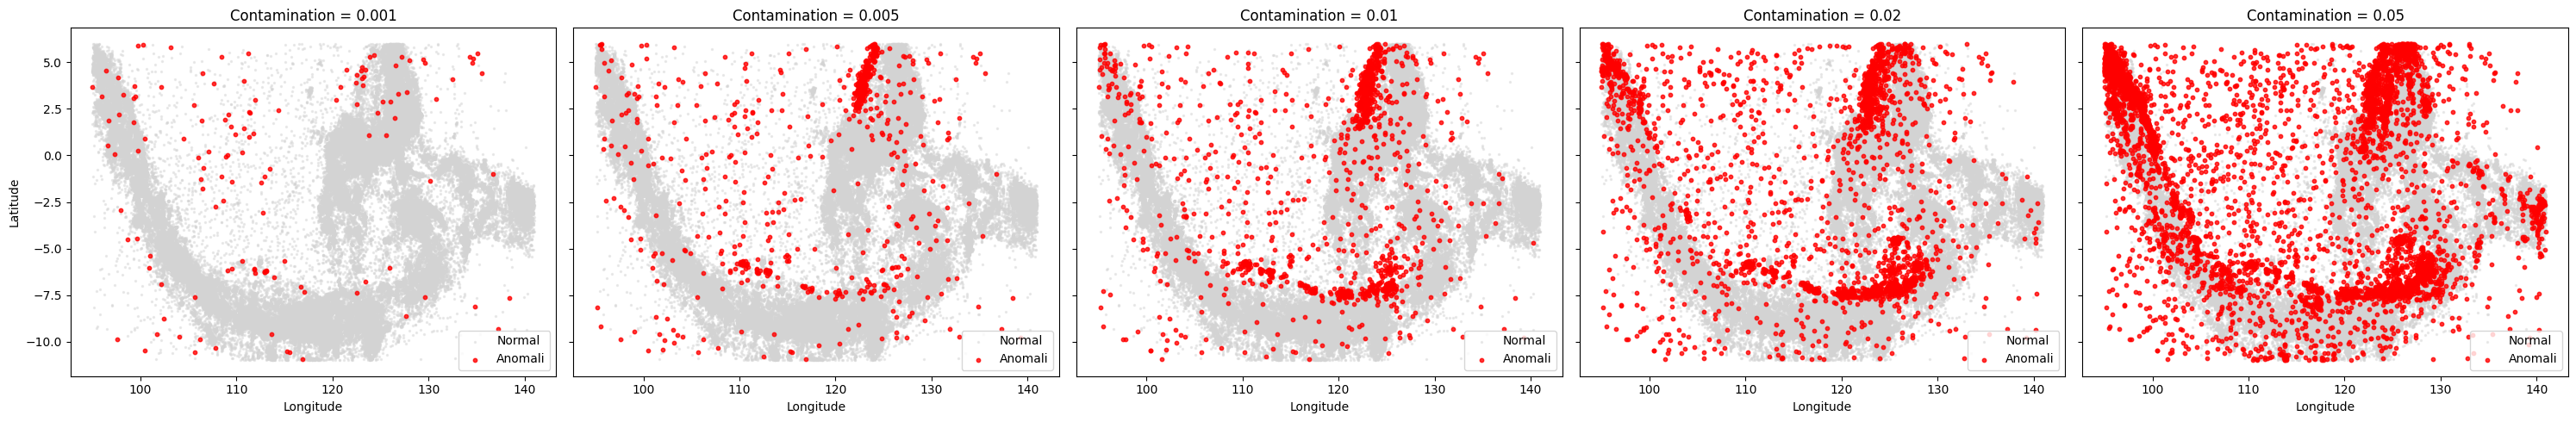

In [14]:
fig, axes = plt.subplots(1, len(contaminations), figsize=(6 * len(contaminations), 5), sharex=True, sharey=True)

for ax, cont in zip(axes, contaminations):
    labels = results[cont]['labels']
    normal_mask = labels == 1
    anomaly_mask = labels == -1

    ax.scatter(df.loc[normal_mask, 'longitude'], df.loc[normal_mask, 'latitude'],
               c='lightgray', alpha=0.4, s=2, label='Normal')
    ax.scatter(df.loc[anomaly_mask, 'longitude'], df.loc[anomaly_mask, 'latitude'],
               c='red', alpha=0.8, s=10, label='Anomali')
    ax.set_title(f'Contamination = {cont}')
    ax.set_xlabel('Longitude')
    ax.legend()

axes[0].set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Distribusi Anomaly Score per Nilai Contamination

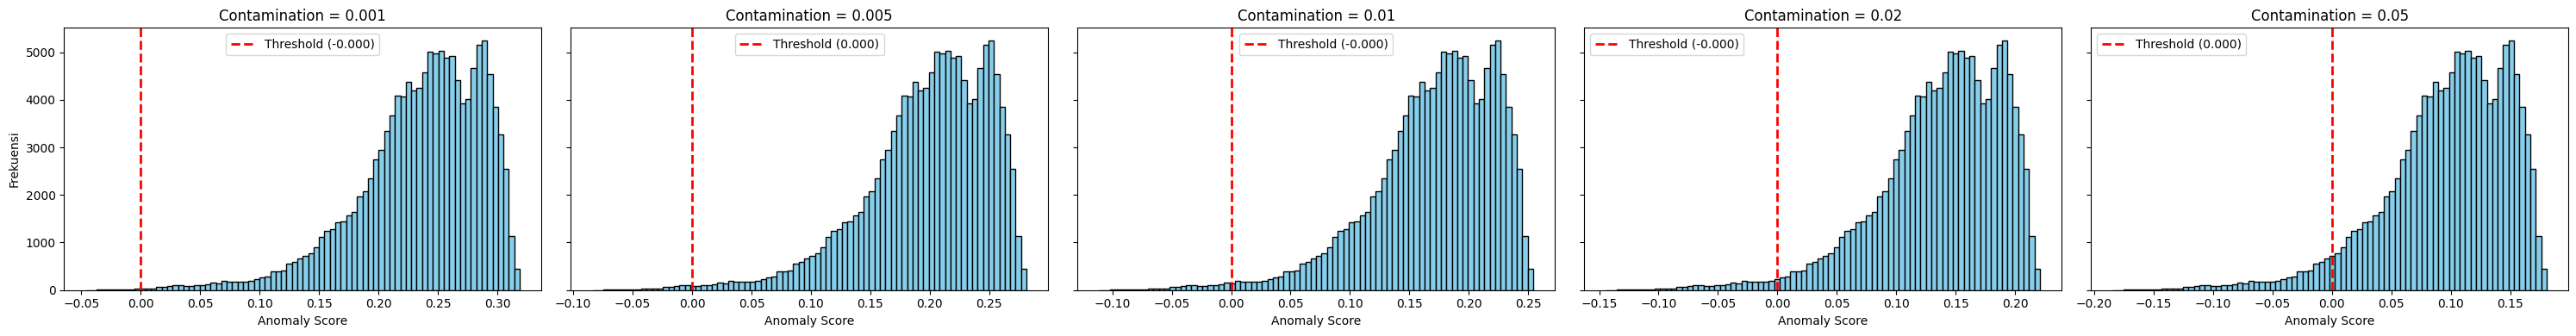

In [15]:
fig, axes = plt.subplots(1, len(contaminations), figsize=(6 * len(contaminations), 4), sharey=True)

for ax, cont in zip(axes, contaminations):
    scores = results[cont]['scores']
    threshold = pd.Series(scores).quantile(cont)
    ax.hist(scores, bins=80, color='skyblue', edgecolor='black')
    ax.axvline(threshold, color='red', linestyle='dashed', linewidth=2,
               label=f'Threshold ({threshold:.3f})')
    ax.set_title(f'Contamination = {cont}')
    ax.set_xlabel('Anomaly Score')
    ax.legend()

axes[0].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()